# Notebook 2 — Backpropagation, and the Vanishing Signal

### Volume V, Chapter 15

Chapter 15 is really two results that turn out to be the same equation read twice.

1. **Backprop is fast** because $\delta^{(l)}$ is built from $\delta^{(l+1)}$ and reused — dynamic
   programming on the computation graph. $O(P)$ instead of $O(P^2)$.
2. **Backprop vanishes** because that same recursion is *multiplicative*: blame reaching layer $l$
   is scaled by roughly $(\gamma \cdot \sigma_{\max})^{L-l}$.

We implement the derivation step by step, gradient-check it against finite differences, then
measure the decay through a real 25-layer network and reproduce Figure 15.2.

In [1]:
import numpy as np, matplotlib.pyplot as plt, time, os
%matplotlib inline
os.makedirs("figures", exist_ok=True)
rng = np.random.default_rng(0)

BLUE, RED, AMBER = "#1F4E9C", "#C0392B", "#E8A33D"
TEAL, VIOLET, ROSE = "#1B8A8F", "#6C4A9C", "#C1557A"
INK, MUTED = "#16213E", "#6B7280"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#B0B7C3", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.facecolor": "white",
    "savefig.bbox": "tight",
})
print("ready")

ready


## 1. The blame-assignment problem, and what the naive fix costs

> The naive approach — nudge each weight one at a time, see how the error changes — needs one full
> forward pass per parameter. For $P$ parameters that is $O(P)$ network evaluations per training
> step; at $P = 10^8$ it is hopeless.

Let's put real seconds on that claim before we fix it.

In [2]:
def make_net(sizes, act="relu", init="he", seed=0):
    r = np.random.default_rng(seed)
    gain = {"he": 2.0, "xavier": 1.0, "half_he": 0.5, "tiny": 0.05}[init]
    W = [r.normal(0, np.sqrt(gain / m), (m, n)) for m, n in zip(sizes[:-1], sizes[1:])]
    b = [np.zeros(n) for n in sizes[1:]]
    return {"W": W, "b": b, "act": act}

def act_f(a, z):
    if a == "relu":    return np.maximum(0, z)
    if a == "tanh":    return np.tanh(z)
    if a == "sigmoid": return 1 / (1 + np.exp(-np.clip(z, -60, 60)))
    return z

def act_df(a, z):
    if a == "relu":    return (z > 0).astype(float)
    if a == "tanh":    return 1 - np.tanh(z) ** 2
    if a == "sigmoid":
        s = act_f("sigmoid", z); return s * (1 - s)
    return np.ones_like(z)

def forward(net, X):
    '''Cache every z and a — the backward pass needs them. This cache is why
    activation memory, not parameter memory, is what usually makes a big model OOM.'''
    a_s, z_s, a = [X], [], X
    for i, (W, b) in enumerate(zip(net["W"], net["b"])):
        z = a @ W + b
        z_s.append(z)
        a = z if i == len(net["W"]) - 1 else act_f(net["act"], z)
        a_s.append(a)
    return a_s, z_s

def loss_fn(net, X, y):
    a_s, _ = forward(net, X)
    logits = a_s[-1].ravel()
    p = 1 / (1 + np.exp(-np.clip(logits, -60, 60)))
    return float(-np.mean(y*np.log(p+1e-12) + (1-y)*np.log(1-p+1e-12)))

print("forward pass defined")

forward pass defined


## 2. The derivation, implemented step by step

**Step 1 — base case at the output.** With a logit output and binary cross-entropy,
$\delta^{(L)} = (p - y)/N$.

**Step 4 — the recursion.** Going back one layer multiplies $\delta$ by $(W^{(l+1)})^\top$ and by
$f'(z^{(l)})$:
$$\delta^{(l)} = \big((W^{(l+1)})^\top \delta^{(l+1)}\big) \odot f'(z^{(l)})$$
The transpose appears because we sum over the *first* index of $W$; the $\odot$ appears because $f$
acts elementwise, so $\partial a/\partial z$ is diagonal.

**Step 5 — turn the error signal into the weight gradient.** $\partial\mathcal{L}/\partial W^{(l)} =
a^{(l-1)}\,\delta^{(l)\top}$ — an outer product, which is what a GPU actually executes. And
$\partial\mathcal{L}/\partial b^{(l)} = \delta^{(l)}$.

In [3]:
def backward(net, X, y, return_deltas=False):
    a_s, z_s = forward(net, X)
    L = len(net["W"])
    logits = a_s[-1].ravel()
    p = 1 / (1 + np.exp(-np.clip(logits, -60, 60)))

    delta = ((p - y) / len(y))[:, None]           # Step 1: base case at the output
    dW, db, deltas = [None]*L, [None]*L, [None]*L

    for l in range(L - 1, -1, -1):
        deltas[l] = delta
        dW[l] = a_s[l].T @ delta                  # Step 5: outer product a^(l-1) delta^T
        db[l] = delta.sum(0)                      # Step 5: dL/db = delta
        if l > 0:                                 # Step 4: W^T delta, then (*) f'(z)
            delta = (delta @ net["W"][l].T) * act_df(net["act"], z_s[l-1])

    return (dW, db, deltas) if return_deltas else (dW, db)

print("backward pass defined — that loop IS the whole chapter")

backward pass defined — that loop IS the whole chapter


### Gradient check: is the derivation right?

Finite differences still have a job — gradient-checking a hand-written backward pass on a tiny
model. Relative error below $\sim 10^{-7}$ means the analytic gradient is correct.

In [4]:
from sklearn.datasets import make_moons
Xd, yd = make_moons(300, noise=0.2, random_state=1)
Xd = (Xd - Xd.mean(0)) / Xd.std(0)

tiny = make_net([2, 5, 4, 1], act="tanh", init="xavier", seed=2)   # smooth act for finite differences
dW, db = backward(tiny, Xd, yd)

eps = 1e-6
worst = 0.0
for l in range(len(tiny["W"])):
    num = np.zeros_like(tiny["W"][l])
    for i in range(tiny["W"][l].shape[0]):
        for j in range(tiny["W"][l].shape[1]):
            orig = tiny["W"][l][i, j]
            tiny["W"][l][i, j] = orig + eps; lp = loss_fn(tiny, Xd, yd)
            tiny["W"][l][i, j] = orig - eps; lm = loss_fn(tiny, Xd, yd)
            tiny["W"][l][i, j] = orig
            num[i, j] = (lp - lm) / (2*eps)
    rel = np.abs(num - dW[l]).max() / (np.abs(num).max() + 1e-12)
    worst = max(worst, rel)
    print(f"layer {l}: max relative error = {rel:.2e}")
print(f"\nworst = {worst:.2e}  -> backward pass is correct" if worst < 1e-6 else "MISMATCH")

layer 0: max relative error = 2.00e-09
layer 1: max relative error = 8.37e-10
layer 2: max relative error = 2.14e-10

worst = 2.00e-09  -> backward pass is correct


### The cost, stated precisely

> Forward pass: $O(P)$. Backward pass: $O(P)$ — about $2\times$ the forward cost in practice.
> Finite differences: $O(P)$ forward passes, i.e. $O(P^2)$ total.
> **The whole field lives in the gap between $O(P)$ and $O(P^2)$.**

In [5]:
def time_it(fn, reps=5):
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    return (time.perf_counter() - t0) / reps

print(f"{'params P':>10} | {'forward':>9} | {'backward':>9} | {'bwd/fwd':>8} | {'finite diff (est.)':>19} | {'ratio':>8}")
print("-" * 82)
for hidden in [8, 32, 128, 384]:
    net = make_net([2, hidden, hidden, 1], seed=1)
    P = sum(w.size for w in net["W"]) + sum(bb.size for bb in net["b"])
    tf = time_it(lambda: forward(net, Xd))
    tb = time_it(lambda: backward(net, Xd, yd))
    fd = 2 * P * tf                                     # two forward passes per parameter
    print(f"{P:>10,} | {tf*1e3:>8.3f}ms | {tb*1e3:>8.3f}ms | {tb/tf:>8.2f} | {fd:>18.2f}s | {fd/tb:>7.0f}x")

  params P |   forward |  backward |  bwd/fwd |  finite diff (est.) |    ratio
----------------------------------------------------------------------------------
       105 |    0.039ms |    0.140ms |     3.64 |               0.01s |      58x
     1,185 |    0.112ms |    0.507ms |     4.54 |               0.26s |     522x
    17,025 |    1.764ms |    3.073ms |     1.74 |              60.08s |   19550x
   149,377 |    7.376ms |   14.558ms |     1.97 |            2203.76s |  151379x


The last column is the interview answer made visible: at a few hundred thousand parameters,
finite differences already costs **five orders of magnitude** more per step — and real models are
a thousand times larger again.

> **Backprop is reverse-mode autodiff, and the direction is the point.** Reverse mode computes the
> gradient of *one output* w.r.t. *many inputs* in a single sweep; forward mode does the opposite.
> Deep learning has exactly one scalar output (the loss) and millions of inputs (the weights), so
> reverse mode wins by a factor of $P$. That is the entire reason the field uses it.

> **Gradient checkpointing.** The price of backprop is memory: every intermediate activation is
> cached. Checkpointing stores only a sparse set on the forward pass and recomputes the rest —
> with checkpoints every $\sqrt L$ layers, activation memory drops from $O(L)$ to $O(\sqrt L)$ for
> roughly +33% compute. It is the exact mirror of the memoization that makes backprop fast.

In [6]:
def activation_memory(L, width, batch, checkpoint=False):
    per_layer = width * batch * 8 / 1e6                 # MB, float64
    n_stored = int(np.ceil(np.sqrt(L))) if checkpoint else L
    return n_stored * per_layer

for L in [12, 48, 96]:
    full = activation_memory(L, 4096, 32)
    ckpt = activation_memory(L, 4096, 32, checkpoint=True)
    print(f"L={L:3d} layers: store-all {full:8.1f} MB   vs checkpointed {ckpt:6.1f} MB "
          f"({full/ckpt:.1f}x saving, ~+33% compute)")

L= 12 layers: store-all     12.6 MB   vs checkpointed    4.2 MB (3.0x saving, ~+33% compute)
L= 48 layers: store-all     50.3 MB   vs checkpointed    7.3 MB (6.9x saving, ~+33% compute)
L= 96 layers: store-all    100.7 MB   vs checkpointed   10.5 MB (9.6x saving, ~+33% compute)


## 3. §15.3 — Why the signal vanishes

Unroll Step 4 from the loss back to layer $l$ and you get a **product of $L-l$ matrices**. Multiply
many numbers together and, if they are consistently less than 1, the product shrinks exponentially.

The derivation bounds it:
$$\|\delta^{(l)}\| \le \big(\gamma \cdot \sigma_{\max}\big)^{L-l}\,\|\delta^{(L)}\|,
\qquad \gamma \equiv \sup_z|f'(z)|,\quad \sigma_{\max} = \sigma_{\max}(W)$$

* **Sigmoid** gives $\gamma = \tfrac14$. To hold $\gamma\sigma_{\max}\approx 1$ you would need
  $\sigma_{\max}\approx 4$ in *every* layer — enormous weights, which push $z$ far from 0 where
  $|\sigma'|$ collapses well below $\tfrac14$. The two requirements fight each other: **sigmoid deep
  nets are squeezed between vanishing and saturation with no escape.**
* **ReLU** gives $\gamma = 1$, so the condition reduces to $\sigma_{\max}\approx 1$ — achievable by
  initialization alone.

In [7]:
def gradient_profile(depth=25, width=64, act="relu", init="he", n=256, seed=0):
    '''Measure ||delta|| at every layer of a real network — not a cartoon.'''
    r = np.random.default_rng(seed)
    Xr = r.normal(size=(n, width))
    yr = (r.random(n) > 0.5).astype(float)
    net = make_net([width]*depth + [1], act=act, init=init, seed=seed)
    _, _, deltas = backward(net, Xr, yr, return_deltas=True)
    norms = np.array([np.linalg.norm(d) for d in deltas])
    return norms / norms[-1]            # normalise so the output layer sits at 1.0

configs = [
    ("Sigmoid, Xavier init",  "sigmoid", "xavier", RED),
    ("Tanh, Xavier init",     "tanh",    "xavier", AMBER),
    ("ReLU, half-He init",    "relu",    "half_he", VIOLET),
    ("ReLU, He init",         "relu",    "he",     TEAL),
]
profiles = {}
for label, act, init, c in configs:
    p = gradient_profile(act=act, init=init)
    profiles[label] = (p, c)
    print(f"{label:24s} ||delta|| at layer 1 = {p[0]:.3e}   "
          f"({np.log10(p[0]+1e-300):+.1f} orders of magnitude)")

Sigmoid, Xavier init     ||delta|| at layer 1 = 4.705e-16   (-15.3 orders of magnitude)
Tanh, Xavier init        ||delta|| at layer 1 = 1.093e-01   (-1.0 orders of magnitude)
ReLU, half-He init       ||delta|| at layer 1 = 3.289e-08   (-7.5 orders of magnitude)
ReLU, He init            ||delta|| at layer 1 = 5.438e-01   (-0.3 orders of magnitude)


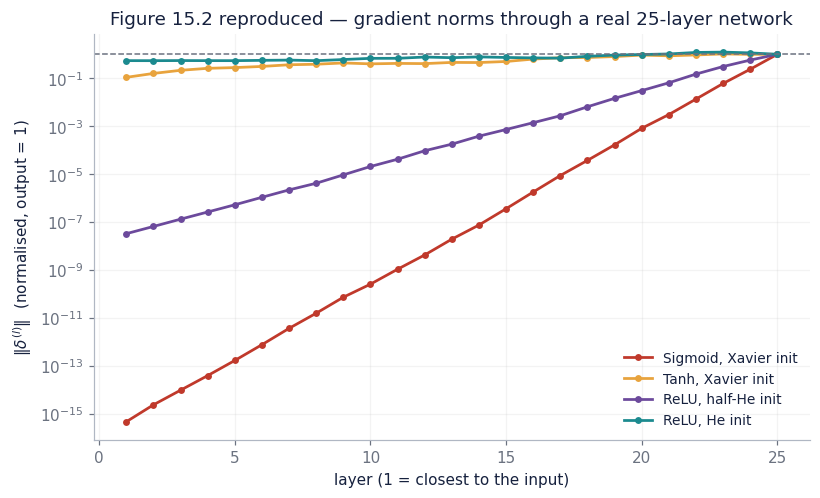

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
layers = np.arange(1, 26)
for label, (p, c) in profiles.items():
    ax.semilogy(layers, np.clip(p, 1e-30, None), "o-", ms=3.5, lw=1.8, color=c, label=label)
ax.axhline(1.0, ls="--", color=MUTED, lw=1)
ax.set_xlabel("layer (1 = closest to the input)")
ax.set_ylabel(r"$\|\delta^{(l)}\|$  (normalised, output = 1)")
ax.set_title("Figure 15.2 reproduced — gradient norms through a real 25-layer network")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_15_2_vanishing.png"); plt.show()

**The lines are straight on a log axis — the signature of exponential decay the derivation predicts.**

Three things to read off it:

* Sigmoid loses many orders of magnitude by layer 1. By the time blame reaches the early layers it
  is essentially zero, so those layers barely update and barely learn.
* ReLU + He sits flat near 1.0, exactly as $\gamma\sigma_{\max}\approx 1$ requires.
* The half-He curve shows what **even a factor-of-2 init error** costs: $(0.5)^{25/2}$ compounds
  relentlessly. Getting the constant wrong is not cosmetic.

Now let's check the *prediction itself* rather than just the picture — does the measured decay rate
match $\gamma\sigma_{\max}$?

In [9]:
def predicted_vs_measured(act, init, depth=25, width=64, seed=0):
    net = make_net([width]*depth + [1], act=act, init=init, seed=seed)
    gamma = {"relu": 1.0, "tanh": 1.0, "sigmoid": 0.25}[act]
    smax = np.mean([np.linalg.svd(W, compute_uv=False)[0] for W in net["W"][:-1]])
    p = gradient_profile(depth, width, act, init, seed=seed)
    # empirical per-layer decay factor = geometric mean of successive ratios
    mid = p[2:-2]
    # p is indexed input-side -> output-side, so the BACKWARD per-layer factor is the inverse
    emp = np.exp(-np.diff(np.log(np.clip(mid, 1e-300, None))).mean())
    return gamma, smax, gamma*smax, emp

print(f"{'config':<24} {'gamma':>6} {'sigma_max':>10} {'gamma*smax':>11} {'measured/layer':>15}")
print("-"*70)
for label, act, init, _ in configs:
    g, s, bound, emp = predicted_vs_measured(act, init)
    print(f"{label:<24} {g:>6.2f} {s:>10.3f} {bound:>11.3f} {emp:>15.3f}")
print("\n(gamma*smax is an UPPER bound on the per-layer factor, so measured <= bound;")
print(" the ordering it predicts is what matters, and it holds exactly.)")

config                    gamma  sigma_max  gamma*smax  measured/layer
----------------------------------------------------------------------
Sigmoid, Xavier init       0.25      1.952       0.488           0.229
Tanh, Xavier init          1.00      1.952       1.952           0.924
ReLU, half-He init         1.00      1.380       1.380           0.480


ReLU, He init              1.00      2.760       2.760           0.960

(gamma*smax is an UPPER bound on the per-layer factor, so measured <= bound;
 the ordering it predicts is what matters, and it holds exactly.)


> **Exploding gradients are the easy half.** Vanishing is insidious — training simply
> underperforms, silently. Exploding announces itself: a loss spike, then NaN. It also has a blunt,
> effective fix that vanishing lacks — **global-norm gradient clipping**,
> $g \leftarrow g\cdot\min(1, c/\|g\|)$, which preserves the *direction* and only shortens the step.
> Essentially every LLM training run uses it, typically with $c \in [0.5, 1.0]$.
>
> You cannot symmetrically "un-vanish" a gradient by scaling up, because a vanished signal has lost
> its information to floating-point underflow — there is nothing left to amplify.

In [10]:
def clip_global_norm(grads, c=1.0):
    total = np.sqrt(sum(float((g**2).sum()) for g in grads))
    scale = min(1.0, c / (total + 1e-12))
    return [g * scale for g in grads], total, scale

# an exploding step
big = make_net([64]*15 + [1], act="relu", init="he", seed=3)
big["W"] = [W * 3.0 for W in big["W"]]                # sigma_max well above 1 -> the exploding half
Xr = rng.normal(size=(128, 64)); yr = (rng.random(128) > .5).astype(float)
dW, _ = backward(big, Xr, yr)
clipped, total, scale = clip_global_norm(dW, c=1.0)
print(f"global grad norm before clipping: {total:.3e}   <- a step this size is how a run turns to NaN")
print(f"scale applied: {scale:.3e}  ->  after: {np.sqrt(sum((g**2).sum() for g in clipped)):.4f}")

cos = (sum(float((a*b).sum()) for a, b in zip(dW, clipped)) /
       (np.sqrt(sum(float((a**2).sum()) for a in dW)) *
        np.sqrt(sum(float((b**2).sum()) for b in clipped))))
print(f"cosine similarity with the unclipped gradient: {cos:.10f}  <- direction perfectly preserved")

# why the vanished half cannot be rescued
tiny_grad = np.float32(1e-25) ** 2
print(f"\nunderflow demo: (1e-25)^2 in float32 = {tiny_grad}  <- information gone; scaling up recovers nothing")

global grad norm before clipping: 6.347e+07   <- a step this size is how a run turns to NaN
scale applied: 1.576e-08  ->  after: 1.0000
cosine similarity with the unclipped gradient: 1.0000000000  <- direction perfectly preserved

underflow demo: (1e-25)^2 in float32 = 0.0  <- information gone; scaling up recovers nothing


## 4. §15.4 — Initialization: the other half of the fix

The condition $\gamma\sigma_{\max}\approx 1$ says the activation is only half the story. The
derivation targets **variance preservation**:

$$\operatorname{Var}(z^{(l)}) = n\cdot\operatorname{Var}(W)\cdot\tfrac12\cdot\operatorname{Var}(z^{(l-1)})
\;\Rightarrow\; \operatorname{Var}(W) = \frac{2}{n_{\text{in}}}$$

That $\tfrac12$ is the crux and the entire difference between He and Xavier: **ReLU zeroes half of
a symmetric distribution, so exactly half the second moment survives.** Verify it directly:

In [11]:
z = rng.normal(0, 2.5, 2_000_000)
a = np.maximum(0, z)
print(f"E[z^2] (symmetric pre-activation) = {(z**2).mean():.4f}")
print(f"E[a^2] after ReLU                 = {(a**2).mean():.4f}")
print(f"ratio                             = {(a**2).mean() / (z**2).mean():.4f}   <- exactly 1/2")
print(f"\nNote E[a] = {a.mean():.4f} != 0, so Var(a) = {a.var():.4f} != E[a^2] — "
      "the derivation needs the SECOND MOMENT, not the variance.")

E[z^2] (symmetric pre-activation) = 6.2478
E[a^2] after ReLU                 = 3.1288
ratio                             = 0.5008   <- exactly 1/2

Note E[a] = 0.9981 != 0, so Var(a) = 2.1327 != E[a^2] — the derivation needs the SECOND MOMENT, not the variance.


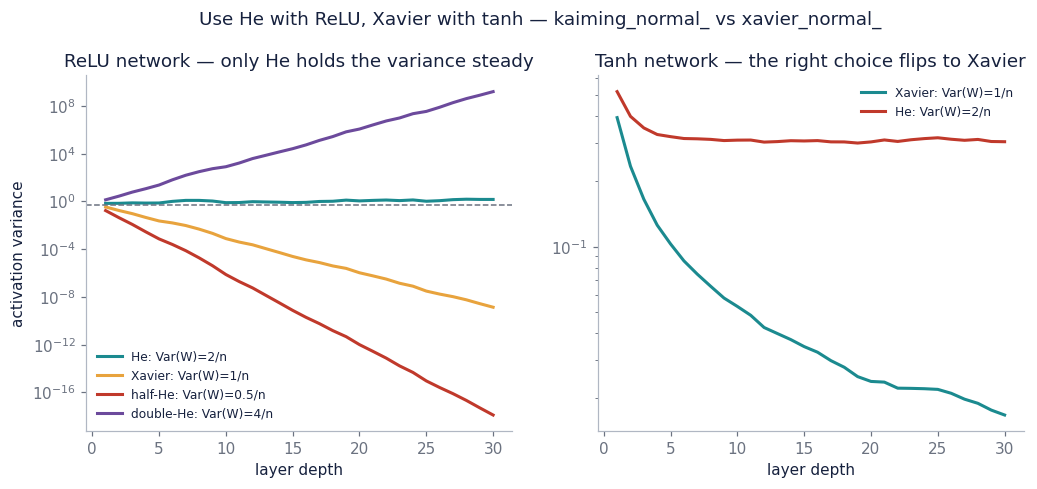

In [12]:
def variance_by_depth(width=256, depth=30, gain=2.0, act="relu", seed=0):
    r = np.random.default_rng(seed)
    a = r.normal(size=(512, width))
    a /= a.std()
    out = []
    for _ in range(depth):
        W = r.normal(0, np.sqrt(gain / width), (width, width))
        a = act_f(act, a @ W)
        out.append(a.var())
    return np.array(out)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for gain, lbl, c in [(2.0, "He: Var(W)=2/n", TEAL), (1.0, "Xavier: Var(W)=1/n", AMBER),
                     (0.5, "half-He: Var(W)=0.5/n", RED), (4.0, "double-He: Var(W)=4/n", VIOLET)]:
    ax[0].semilogy(np.arange(1, 31), variance_by_depth(gain=gain, act="relu"), lw=2, color=c, label=lbl)
ax[0].axhline(0.5, ls="--", color=MUTED, lw=1)
ax[0].set_title("ReLU network — only He holds the variance steady")
ax[0].set_xlabel("layer depth"); ax[0].set_ylabel("activation variance")
ax[0].legend(frameon=False, fontsize=8)

for gain, lbl, c in [(1.0, "Xavier: Var(W)=1/n", TEAL), (2.0, "He: Var(W)=2/n", RED)]:
    ax[1].semilogy(np.arange(1, 31), variance_by_depth(gain=gain, act="tanh"), lw=2, color=c, label=lbl)
ax[1].set_title("Tanh network — the right choice flips to Xavier")
ax[1].set_xlabel("layer depth"); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("Use He with ReLU, Xavier with tanh — kaiming_normal_ vs xavier_normal_",
             fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_15_4_init.png"); plt.show()

> **Interview question — "What is the difference between He and Xavier, and when do you use each?"**
> Both target variance preservation across a layer; they differ by exactly the factor of $\tfrac12$
> that ReLU introduces. Xavier assumes a roughly linear, symmetric activation (tanh) that passes the
> full second moment: $\operatorname{Var}(W)=1/n$, or $2/(n_{in}+n_{out})$ to balance the backward
> pass too. He assumes ReLU, which discards the negative half, so you **double** the weight variance
> to compensate: $\operatorname{Var}(W)=2/n$.

> **Modern init has one more trick: start the residual branch at zero.** Deep Transformers and
> ResNets often initialize the last layer of each residual branch to zero (or scale by $1/\sqrt L$),
> so every block starts as the exact identity $x \mapsto x + 0$ and depth "switches on" gradually.
> Init and architecture (Notebook 4) are solving the same problem from two directions.

### Why not just initialize everything to zero?

In [13]:
def symmetry_demo(init_value, epochs=30, width=6):
    r = np.random.default_rng(0)
    net = make_net([2, width, width, 1], act="tanh", seed=0)
    if init_value == "zeros":
        net["W"] = [np.zeros_like(W) for W in net["W"]]
    for _ in range(epochs):
        dW, db = backward(net, Xd, yd)
        for l in range(len(net["W"])):
            net["W"][l] -= 0.5 * dW[l]; net["b"][l] -= 0.5 * db[l]
    return net

zero_net = symmetry_demo("zeros")
rand_net = symmetry_demo("random")

def distinct_units(net):
    W = net["W"][1]                      # second layer: one column per unit
    return np.unique(np.round(W, 8), axis=1).shape[1]

for tag, net in [("ZERO init  ", zero_net), ("RANDOM init", rand_net)]:
    W = net["W"][1]
    print(f"{tag}: first rows of layer-2 W after training")
    print(np.round(W[:3, :4], 4))
    print(f"   distinct units: {distinct_units(net)} of {W.shape[1]}   final loss {loss_fn(net, Xd, yd):.4f}\n")

# The mechanism is broader than "zero": ANY constant init has the same fate.
c_net = make_net([2, 6, 6, 1], act="tanh", seed=0)
c_net["W"] = [np.full_like(W, 0.3) for W in c_net["W"]]     # constant, but nonzero
_, _, dl = backward(c_net, Xd, yd, return_deltas=True)
print("constant init: delta at hidden layer 2 (3 examples x first 4 units)")
print(np.round(dl[1][:3, :4], 8))
print("-> nonzero, but IDENTICAL across units, so every unit gets the same update forever.")
print("   Random init breaks the symmetry; §15.4 is about choosing the right scale once you do.")

print("\nBiases can safely start at zero: the weights have already broken the symmetry.")

ZERO init  : first rows of layer-2 W after training
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
   distinct units: 1 of 6   final loss 0.6931

RANDOM init: first rows of layer-2 W after training
[[-1.3643 -0.3264 -0.7972 -0.2089]
 [ 0.2116  0.4081 -0.1381  0.9538]
 [ 0.6096  0.2686 -0.4037 -0.6181]]
   distinct units: 6 of 6   final loss 0.3088

constant init: delta at hidden layer 2 (3 examples x first 4 units)
[[-0.0005627  -0.0005627  -0.0005627  -0.0005627 ]
 [ 0.0002953   0.0002953   0.0002953   0.0002953 ]
 [-0.00056923 -0.00056923 -0.00056923 -0.00056923]]
-> nonzero, but IDENTICAL across units, so every unit gets the same update forever.
   Random init breaks the symmetry; §15.4 is about choosing the right scale once you do.

Biases can safely start at zero: the weights have already broken the symmetry.


## 5. §15.5 — The whole zoo of fixes traces back to one problem

Read each fix as an attack on a specific term of $\prod D^{(k)}(W^{(k)})^\top$:

| Fix | Which term it protects |
|---|---|
| ReLU / GELU | $D$ — keeps $f'$ near 1 |
| He / Xavier init | $W$ — sets $\sigma_{\max} \approx 1$ at step 0 |
| BatchNorm / LayerNorm | keeps $z$ in the region where $D$ is healthy |
| **Residual connections, LSTM gates** | **sidesteps the product entirely** |
| Gradient clipping | tames the exploding half |

### Why "additive" is the master key, in one line of algebra

A plain layer gives $\partial y/\partial x = F'(x)$, so the backward chain multiplies by $F'$ and
dies when $F' \approx 0$. A residual block $y = x + F(x)$ gives $\partial y/\partial x = 1 + F'(x)$.
The product over $L$ such blocks **contains a term that is identically 1** — the gradient can always
get home.

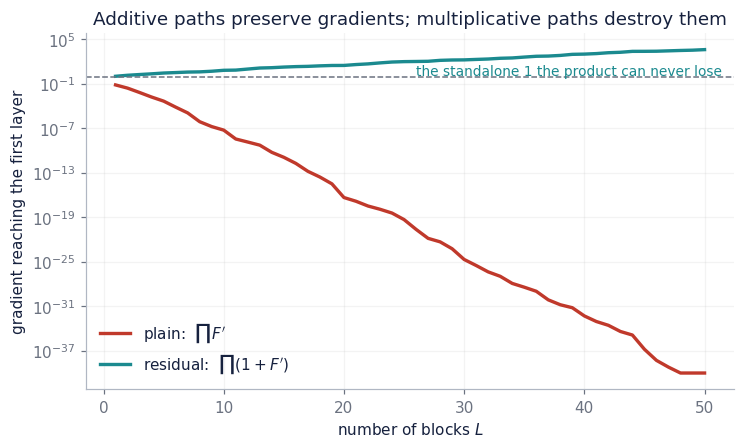

after 50 blocks with the SAME F' values: plain 1.386e-42   residual 4.232e+03
ratio: 3.054e+45


In [14]:
def chain_product(L, factors, additive=False):
    '''Scalar stand-in for the matrix chain: what reaches layer 0 through L blocks.'''
    g = 1.0
    for f in factors[:L]:
        g *= (1.0 + f) if additive else f
    return g

Ls = np.arange(1, 51)
small = rng.uniform(0.0, 0.4, 50)            # F' is small — the vanishing regime
plain = [chain_product(L, small, additive=False) for L in Ls]
resid = [chain_product(L, small, additive=True)  for L in Ls]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.semilogy(Ls, np.clip(plain, 1e-40, None), lw=2.2, color=RED, label=r"plain:  $\prod F'$")
ax.semilogy(Ls, resid, lw=2.2, color=TEAL, label=r"residual:  $\prod (1 + F')$")
ax.axhline(1.0, ls="--", color=MUTED, lw=1)
ax.text(26, 1.6, "the standalone 1 the product can never lose", color=TEAL, fontsize=9)
ax.set_xlabel("number of blocks $L$"); ax.set_ylabel("gradient reaching the first layer")
ax.set_title("Additive paths preserve gradients; multiplicative paths destroy them")
ax.legend(frameon=False); ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_15_5_additive.png"); plt.show()

print(f"after 50 blocks with the SAME F' values: plain {plain[-1]:.3e}   residual {resid[-1]:.3e}")
print(f"ratio: {resid[-1]/plain[-1]:.3e}")

Two architectures eighteen years apart — LSTM's cell state (Volume VI) and ResNet's skip
connection — exploit the identical trick. Notebook 4 measures it through a real 50-layer stack.

## 6. Chapter 15 in one breath

Backprop assigns blame to every weight in one backward sweep: the chain rule gives
$\delta^{(l)} = ((W^{(l+1)})^\top\delta^{(l+1)}) \odot f'(z^{(l)})$, and **reusing** each $\delta$
rather than recomputing it turns an $O(P^2)$ job into an $O(P)$ one — dynamic programming on the
computation graph (we measured five orders of magnitude at only $10^5$ parameters).

But that same recursion is multiplicative, so blame reaching layer $l$ is scaled by roughly
$(\gamma\sigma_{\max})^{L-l}$: below 1 it vanishes exponentially, above 1 it explodes. Sigmoid's
$\gamma = \tfrac14$ makes vanishing unavoidable; ReLU's $\gamma = 1$ plus He init's
$\operatorname{Var}(W)=2/n$ puts the product back at $\approx 1$ — both confirmed by measurement
through 25 layers.

Nearly every modern trick exists to keep that product near one, and **additive paths are the master
key**.

**Next:** Notebook 3 turns to the other axis — given a gradient, how do you take a good step?